In [1]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': [
        'Historical Average',
        'Window Average (12m)',
        'Seasonal Naive',
        'Naive',
        'Exponential Smoothing',
        'ARIMA(1,1,2)',
        'Random Forest',
        'XGBoost',
        'LSTM'
    ],
    'Type': [
        'Baseline', 'Baseline', 'Baseline', 'Baseline',
        'Statistical', 'Statistical',
        'Machine Learning', 'Machine Learning',
        'Deep Learning'
    ],
    'MAE': [
        2488.44, 1184.66, 1157.09, 1129.51,
        1115.83, 1096.23,
        1158.22, 1175.68,
        387.57
    ]
}).sort_values('MAE').reset_index(drop=True)

print(results.to_string(index=False))

                Model             Type     MAE
                 LSTM    Deep Learning  387.57
         ARIMA(1,1,2)      Statistical 1096.23
Exponential Smoothing      Statistical 1115.83
                Naive         Baseline 1129.51
       Seasonal Naive         Baseline 1157.09
        Random Forest Machine Learning 1158.22
              XGBoost Machine Learning 1175.68
 Window Average (12m)         Baseline 1184.66
   Historical Average         Baseline 2488.44


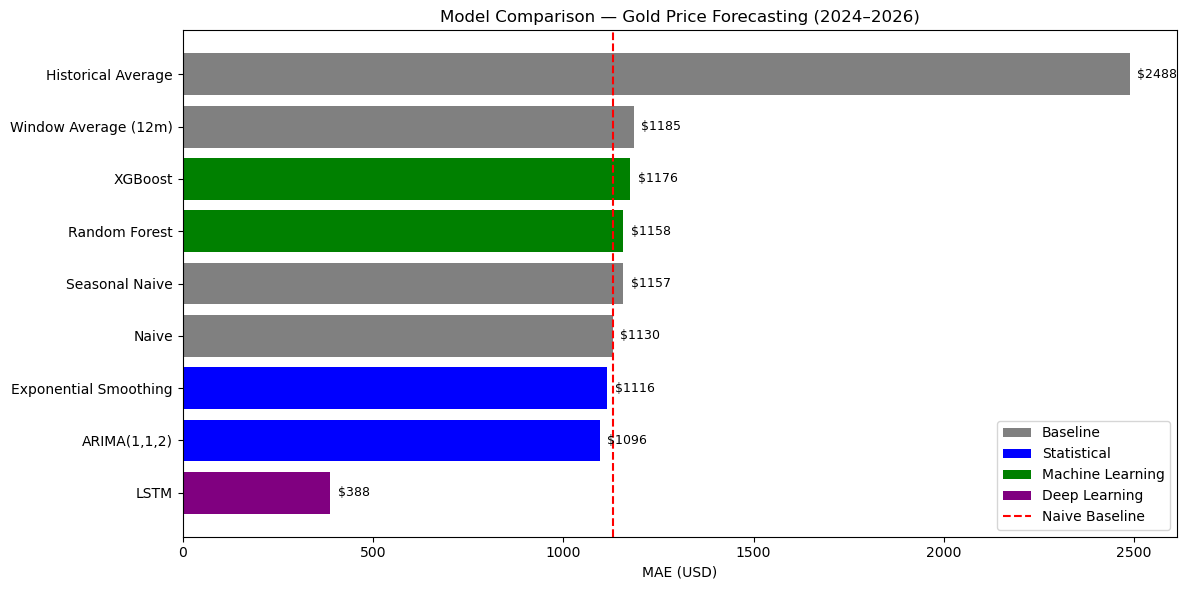

In [2]:
colors = {
    'Baseline': 'gray',
    'Statistical': 'blue', 
    'Machine Learning': 'green',
    'Deep Learning': 'purple'
}

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    results['Model'], 
    results['MAE'],
    color=[colors[t] for t in results['Type']]
)

ax.axvline(x=1129.51, color='red', linestyle='--', linewidth=1.5, label='Naive Baseline (MAE=1130)')
ax.set_xlabel('MAE (USD)')
ax.set_title('Model Comparison — Gold Price Forecasting (2024–2026)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label='Naive Baseline'))
ax.legend(handles=legend_elements, loc='lower right')

for bar, mae in zip(bars, results['MAE']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'${mae:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()